In [151]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer.primitives import SamplerV2
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes

In [152]:
simulator = AerSimulator()

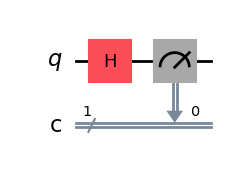

In [153]:
# implement the circuit

qc = QuantumCircuit(1, 1)

qc.h(0)

qc.measure(0, 0)

qc.draw(output='mpl')

In [154]:
pqc = transpile(qc, simulator)
job = simulator.run(qc, shots=1000)

In [155]:
job_result = job.result()

(array([513.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 487.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

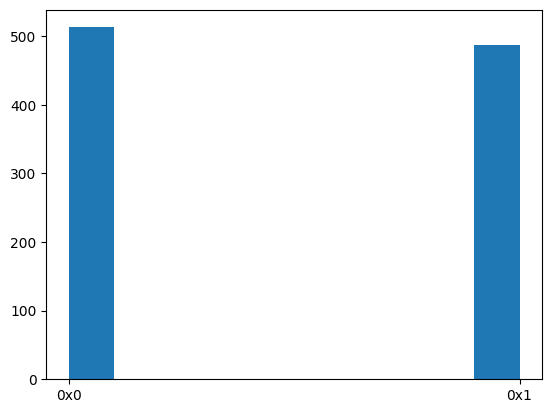

In [156]:
# extract the counts
counts = job_result.results[0].data.counts

plt.hist(['0x0', '0x1'], weights=[counts['0x0'], counts['0x1']])